#Goal: Build a prototype that uses LLMs to extract signals from EDGAR filings and test whether they predict S&P 500 stock returns better than baseline sentiment methods.

In [ ]:
!pip install sec_edgar_downloader

import pandas as pd
import os
from sec_edgar_downloader import Downloader
from bs4 import BeautifulSoup
import nltk
import re

#Step 1) Import Data
tickers = ["AAPL","MSFT","AMZN","GOOGL","META",
           "NVDA","TSLA","JPM","UNH","XOM",
           "PG","KO","HD","PFE","BAC",
           "NFLX","INTC","V","PEP","CVX"]
dl = Downloader("Your Company Name", "your.email@example.com")

for ticker in tickers:
  dl.get("10-K", ticker, limit=2)

filings = []

for ticker in tickers:
  base_dir =  f"sec-edgar-filings/{ticker}/10-K"
  for root, dirs, files in os.walk(base_dir):
    for file in files:
      if file.endswith(".txt"):
          path = os.path.join(root, file)
          with open(path, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()
            filings.append({"ticker":ticker, "form": "10-k", "path":path, "text":text})
df = pd.DataFrame(filings)
print(df.head())

def extract_primary_text_min(raw: str) -> str:
    # 1) choose first DOCUMENT with TYPE 10-K
    docs = re.split(r'(?i)<DOCUMENT>', raw)
    chosen = None
    for d in docs:
        m = re.search(r'(?im)^<TYPE>\s*([A-Z0-9\-/]+)', d)
        if not m:
            continue
        typ = m.group(1).upper()
        if typ in {"10-K", "10-K/A", "10-Q", "10-Q/A"}:
            chosen = d
            break
    if chosen is None:
        chosen = raw


    mtext = re.search(r'(?is)<TEXT>(.*)</TEXT>', chosen)
    content = mtext.group(1) if mtext else chosen

    soup = BeautifulSoup(content, "lxml")  # FIX: 'lxml' (not 'lmxl')
    txt = soup.get_text("\n")

    return (txt.replace("\r\n", "\n")
               .replace("\xa0", " ")
               .replace("’", "'"))

df["plain_text"] = df["text"].apply(extract_primary_text_min)

def extract_primary_text_min(raw:str) -> str:
  #Find the first document whose type looks like 10K
  docs = re.split(r'(?i)<DOCUMENT>', raw)
  chosen = None
  for d in docs:
    m = re.search(r'(?im)^<TYPE>\s*([A-Z0-9\-/]+)', d)
    if not m:
      continue
    typ = m.group(1).upper()
    if typ in {"10-K","10-K/A","10-Q","10-Q/A"}:
      chosen = d
      break
  if chosen is None:
    chosen = raw
  mtext = re.search((r'(?is)<TEXT>(.*)</TEXT>', chosen))
  content = mtext.group(1) if mtext else chosen

  soup = BeautifulSoup(content,'lmxl')
  txt = soup.get_text("\n")

  return (txt.replace("\r\n","\n")
              .replace("\xa0"," ")
              .replace("’","'"))

  df["plain_text"] = df["text"].apply(extract_primary_text_min)

  df["mda_text"], df["risk_text"] = zip(*df["plain_text"].apply(lambda t: extract_sections(t, form="10-K")))
  df["mda_len"] = df["mda_text"].fillna("").str.len()
  df["risk_len"] = df["risk_text"].fillna("").str.len()


ITEM_HEADING_RE = re.compile(r"\n\s*Item\s+([0-9]{1,2}[A]?)\s*\.\s*(.*?)\n", flags=re.IGNORECASE)

# Carve out MD&A and Risk Factors
ITEM_HEADING_RE = re.compile(r'(?im)^\s*Item\s+([0-9]{1,2}A?)\s*\.\s*(.+)$')

def extract_sections(text: str, form: str = "10-K"):
    norm = (text.replace("’", "'")
                .replace("–", "-")
                .replace("\r\n", "\n"))

    matches = list(ITEM_HEADING_RE.finditer(norm))
    if not matches:
        return None, None

    starts = [m.start() for m in matches] + [len(norm)]
    nums   = [m.group(1).strip().lower() for m in matches]
    titles = [m.group(2).strip().lower() for m in matches]

    mda_chunks, risk_chunks = [], []

    for i in range(len(matches)):
        s, e = starts[i], starts[i+1]
        num   = nums[i]
        title = titles[i]
        chunk = norm[s:e].strip()


        if (form.upper() == "10-K" and num == "7") or \
           (form.upper() == "10-Q" and num == "2") or \
           ("management" in title and "discussion" in title):
            mda_chunks.append(chunk)


        if num == "1a" or "risk factor" in title:
            risk_chunks.append(chunk)

    mda_text  = max(mda_chunks, key=len) if mda_chunks else None
    risk_text = max(risk_chunks, key=len) if risk_chunks else None
    return mda_text, risk_text


df["mda_text"] = None
df["risk_text"] = None

for i, txt in df["plain_text"].items():
    try:
        mda, risk = extract_sections(txt, form="10-K")
    except Exception:
        mda, risk = None, None
    df.at[i, "mda_text"] = mda
    df.at[i, "risk_text"] = risk


df["mda_len"]  = df["mda_text"].fillna("").astype(str).str.len()
df["risk_len"] = df["risk_text"].fillna("").astype(str).str.len()

print("Parsed filings summary:")
print(df[["ticker", "form", "mda_len", "risk_len"]].head())


df.to_csv("day1_filings_with_sections.csv", index=False)
print("day1_filings_with_sections.csv saved.")






  ticker  form                                               path  \
0   AAPL  10-k  sec-edgar-filings/AAPL/10-K/0000320193-24-0001...   
1   AAPL  10-k  sec-edgar-filings/AAPL/10-K/0000320193-23-0001...   
2   MSFT  10-k  sec-edgar-filings/MSFT/10-K/0000950170-24-0878...   
3   MSFT  10-k  sec-edgar-filings/MSFT/10-K/0000950170-25-1002...   
4   AMZN  10-k  sec-edgar-filings/AMZN/10-K/0001018724-25-0000...   

                                                text  
0  <SEC-DOCUMENT>0000320193-24-000123.txt : 20241...  
1  <SEC-DOCUMENT>0000320193-23-000106.txt : 20231...  
2  <SEC-DOCUMENT>0000950170-24-087843.txt : 20240...  
3  <SEC-DOCUMENT>0000950170-25-100235.txt : 20250...  
4  <SEC-DOCUMENT>0001018724-25-000004.txt : 20250...  
Parsed filings summary:
  ticker  form  mda_len  risk_len
0   AAPL  10-k    15451     71550
1   AAPL  10-k    15594     67998
2   MSFT  10-k    58352     83565
3   MSFT  10-k    53498     78681
4   AMZN  10-k    48721     63561
day1_filings_with_sections.

In [ ]:
!pip install -q transformers torch vaderSentiment
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import torch

na_rates = df[["mda_text","risk_text"]].isna().mean().rename(lambda c: f"pct_na_{c}")
print("Missing section rates:", na_rates.to_dict())

if "mda_len" in df.columns and "risk_len" in df.columns:
    print("mda_len describe:\n", df["mda_len"].describe())
    print("risk_len describe:\n", df["risk_len"].describe())
else:
    df["mda_len_tmp"]  = df["mda_text"].fillna("").str.len()
    df["risk_len_tmp"] = df["risk_text"].fillna("").str.len()
    print("mda_len_tmp describe:\n", df["mda_len_tmp"].describe())
    print("risk_len_tmp describe:\n", df["risk_len_tmp"].describe())

#Step 2)Signal Extraction
analyzer = SentimentIntensityAnalyzer()

def vader_compound(text: str) -> float:
  if not isinstance(text, str) or not text.strip():
    return 0.0
  return analyzer.polarity_scores(text)["compound"]

df["mda_vader"] = df["mda_text"].apply(vader_compound)
df["risk_vader"] = df["risk_text"].apply(vader_compound)

# Verify VADER sentiment extraction
print(df[["ticker", "mda_vader","risk_vader"]].head())
print("mda_vader describe:\n", df["mda_vader"].describe())
print("risk_vader describe:\n", df["risk_vader"].describe())

import numpy as np

finbert_model_name = "yiyanghkust/finbert-tone"
tokenizer = AutoTokenizer.from_pretrained(finbert_model_name)
model = AutoModelForSequenceClassification.from_pretrained(finbert_model_name)

device = torch.device("cuda" if torch.cuda.is_available () else "cpu")
model.to(device)
model.eval()

def finbert_score_one(text: str):
    try:
        if not isinstance(text, str) or not text.strip():
            return {"pos": 0.0, "neu": 0.0, "neg": 0.0, "score": 0.0}
        inputs = tokenizer(
            text,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model(**inputs)
        logits = outputs.logits[0].detach().cpu().numpy()   # [neg, neu, pos]
        exp = np.exp(logits)
        probs = exp / exp.sum()
        neg, neu, pos = probs.tolist()
        return {"pos": pos, "neu": neu, "neg": neg, "score": pos - neg}
    except Exception:
        return {"pos": 0.0, "neu": 0.0, "neg": 0.0, "score": 0.0}

#apply MDA and risk Factors
mda_results = df["mda_text"].apply(finbert_score_one)
risk_results = df["risk_text"].apply(finbert_score_one)

mda_df  = mda_results.apply(lambda d: d if isinstance(d, dict) else {"pos":0.0,"neu":0.0,"neg":0.0,"score":0.0}).apply(pd.Series)
risk_df = risk_results.apply(lambda d: d if isinstance(d, dict) else {"pos":0.0,"neu":0.0,"neg":0.0,"score":0.0}).apply(pd.Series)

mda_df.columns  = [f"mda_fin_{c}" for c in mda_df.columns]     # pos, neu, neg, score
risk_df.columns = [f"risk_fin_{c}" for c in risk_df.columns]

df = pd.concat([df, mda_df, risk_df], axis=1)


print(df[["ticker", "mda_fin_score", "risk_fin_score"]].head())
print("mda_fin_score describe:\n", df["mda_fin_score"].describe())
print("risk_fin_score describe:\n", df["risk_fin_score"].describe())

cols_keep = ["ticker","form","mda_fin_score","risk_fin_score","mda_vader","risk_vader"]
slim = df[[c for c in cols_keep if c in df.columns]].copy()
slim.to_csv("day2_sentiment_signals.csv", index=False)
print("Saved day2_sentiment_signals.csv")

Missing section rates: {'pct_na_mda_text': 0.0, 'pct_na_risk_text': 0.0}
mda_len describe:
 count        40.000000
mean      47351.275000
std       59193.282731
min         235.000000
25%        2102.500000
50%       38987.500000
75%       58327.250000
max      264279.000000
Name: mda_len, dtype: float64
risk_len describe:
 count        40.000000
mean      93592.125000
std       65256.842651
min         108.000000
25%       65391.000000
50%       77701.000000
75%      101756.250000
max      304528.000000
Name: risk_len, dtype: float64
  ticker  mda_vader  risk_vader
0   AAPL     0.9822     -0.9431
1   AAPL    -0.9066     -0.9987
2   MSFT     0.9999      0.9857
3   MSFT     0.9999      0.9702
4   AMZN     0.9999      0.9990
mda_vader describe:
 count    40.000000
mean      0.632750
std       0.596277
min      -0.906600
25%       0.273200
50%       0.999900
75%       1.000000
max       1.000000
Name: mda_vader, dtype: float64
risk_vader describe:
 count    40.000000
mean      0.565620
st

DataFrame before dropping NaT dates:
  ticker                                               path       date
0   AAPL  sec-edgar-filings/AAPL/10-K/0000320193-24-0001... 2023-10-01
1   AAPL  sec-edgar-filings/AAPL/10-K/0000320193-23-0001... 2022-09-25
2   MSFT  sec-edgar-filings/MSFT/10-K/0000950170-24-0878... 2021-07-01
3   MSFT  sec-edgar-filings/MSFT/10-K/0000950170-25-1002... 2025-06-30
4   AMZN  sec-edgar-filings/AMZN/10-K/0001018724-25-0000... 2024-01-01
Number of rows with NaT dates: 0
Number of rows with valid dates: 40
  ticker       date    t0_date  fwd5_ret  fwd21_ret
0   AAPL 2023-10-01 2023-10-02  0.030158  -0.017151
1   AAPL 2022-09-25 2022-09-26 -0.055183   0.010413
2   MSFT 2021-07-01 2021-07-01  0.023343   0.048675
3   MSFT 2025-06-30 2025-06-30 -0.001588   0.031825
4   AMZN 2024-01-01 2024-01-02  0.009604   0.062362
Rows after cleaning: 40
Date range: 2021-07-01 00:00:00 → 2025-06-30 00:00:00
Train rows: 36  Test rows: 4
          model   r2_test  rank_corr_test
0    VA

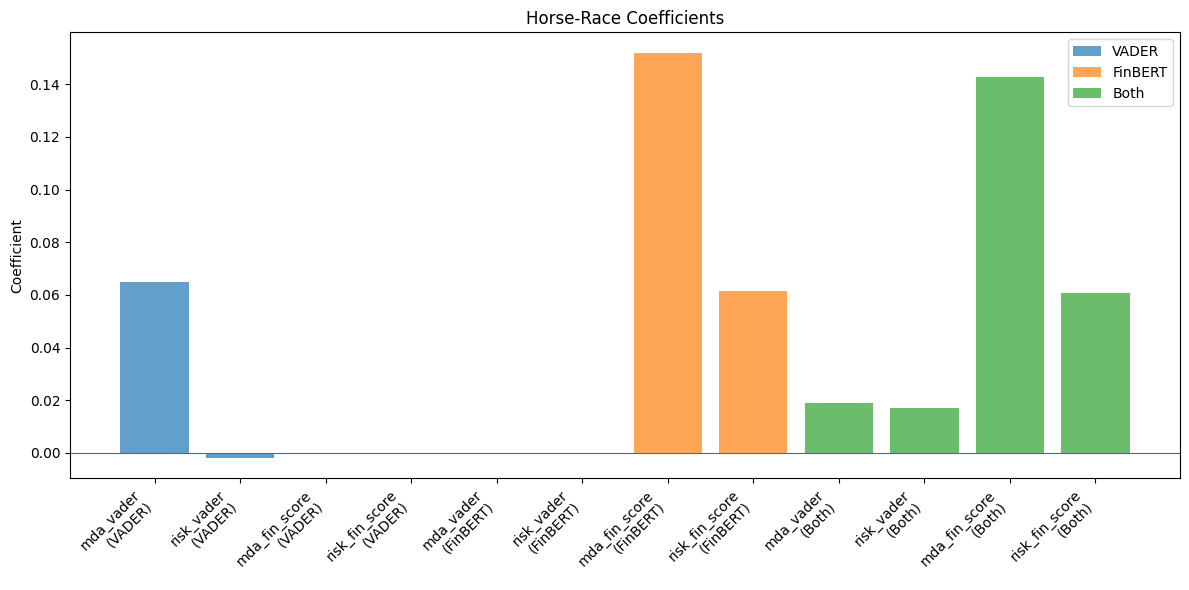

Saved day3_signals_with_targets.csv and day3_coefficients.png


In [ ]:
!pip install -q yfinance
import yfinance as yf
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Step 3) Build targets and model relationships (Horse-Race Regression)
def _find_date_any(s: str):
    if not isinstance(s, str):
        return None
    m = re.search(r"(20\d{2})-(\d{2})-(\d{2})", s)  # YYYY-MM-DD
    if m:
        return f"{m.group(1)}-{m.group(2)}-{m.group(3)}"
    m = re.search(r"(20\d{2})(\d{2})(\d{2})", s)    # YYYYMMDD
    if m:
        return f"{m.group(1)}-{m.group(2)}-{m.group(3)}"
    return None

def guess_filing_date(row):
    for src in ("plain_text", "text", "path"):
        d = _find_date_any(str(row.get(src, "")))
        if d:
            try:
                return pd.to_datetime(d)
            except Exception:
                pass
    return pd.NaT

df = df.copy()
df["date"] = df.apply(guess_filing_date, axis=1)

print("DataFrame before dropping NaT dates:")
print(df[["ticker", "path", "date"]].head())
print(f"Number of rows with NaT dates: {df['date'].isna().sum()}")
print(f"Number of rows with valid dates: {df['date'].notna().sum()}")

df = df.dropna(subset=["date"]).reset_index(drop=True)

tickers = sorted(df["ticker"].dropna().unique().tolist())
start = (df["date"].min() - pd.Timedelta(days=10)).strftime("%Y-%m-%d")
end   = (df["date"].max() + pd.Timedelta(days=35)).strftime("%Y-%m-%d")


data = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
px = data["Close"]
if isinstance(px, pd.Series):
    px = px.to_frame(name=tickers[0])
px = px.sort_index().ffill()

t0_date, t0_close, fwd5_ret, fwd21_ret = [], [], [], []
for _, row in df.iterrows():
    tkr = row["ticker"]
    s = px[tkr].dropna()
    idx = s.index.searchsorted(row["date"], side="left")
    if idx >= len(s):
        t0_date.append(pd.NaT); t0_close.append(np.nan)
        fwd5_ret.append(np.nan); fwd21_ret.append(np.nan)
        continue
    t0_date.append(s.index[idx]); t0_close.append(s.iloc[idx])
    idx5  = min(idx + 5,  len(s) - 1)
    idx21 = min(idx + 21, len(s) - 1)
    fwd5_ret.append(s.iloc[idx5]  / s.iloc[idx] - 1.0)
    fwd21_ret.append(s.iloc[idx21] / s.iloc[idx] - 1.0)

df["t0_date"]   = t0_date
df["t0_close"]  = t0_close
df["fwd5_ret"]  = fwd5_ret
df["fwd21_ret"] = fwd21_ret

print(df[["ticker", "date", "t0_date", "fwd5_ret", "fwd21_ret"]].head())

data = df.copy()
y_col = "fwd21_ret"
features_vader   = ["mda_vader", "risk_vader"]
features_finbert = ["mda_fin_score", "risk_fin_score"]
features_both    = features_vader + features_finbert

needed_cols = ["ticker", "date", y_col] + features_both
data = (
    data[needed_cols]
    .dropna()
    .sort_values(["date"])
    .reset_index(drop=True)
)

print("Rows after cleaning:", len(data))
print("Date range:", data["date"].min(), "→", data["date"].max())

split_date = data["date"].quantile(0.70)
train = data[data["date"] <= split_date].copy()
test  = data[data["date"] >  split_date].copy()

print("Train rows:", len(train), " Test rows:", len(test))
assert len(train) > 0 and len(test) > 0, "Need some rows on each side of the split."

def fit_and_score(Xcols):
    lr = LinearRegression()
    lr.fit(train[Xcols], train[y_col])
    yhat = lr.predict(test[Xcols])
    r2 = r2_score(test[y_col], yhat)
    y_rank  = test[y_col].rank(method="average")
    yh_rank = pd.Series(yhat, index=test.index).rank(method="average")
    rank_corr = y_rank.corr(yh_rank)
    return {
        "features": Xcols,
        "r2_test": float(r2),
        "rank_corr_test": float(rank_corr),
        "coef": dict(zip(Xcols, lr.coef_)),
    }

res_vader   = fit_and_score(features_vader)
res_finbert = fit_and_score(features_finbert)
res_both    = fit_and_score(features_both)

summary = pd.DataFrame([
    {"model": "VADER only",   "r2_test": res_vader["r2_test"],   "rank_corr_test": res_vader["rank_corr_test"]},
    {"model": "FinBERT only", "r2_test": res_finbert["r2_test"], "rank_corr_test": res_finbert["rank_corr_test"]},
    {"model": "Both",         "r2_test": res_both["r2_test"],    "rank_corr_test": res_both["rank_corr_test"]},
])
print(summary)

print("\nCoefficients (interpretability):")
print("VADER:",   res_vader["coef"])
print("FinBERT:", res_finbert["coef"])
print("Both:",    res_both["coef"])

summary.to_csv("day3_model_summary.csv", index=False)
print("[✓] Saved day3_model_summary.csv")

coef_df = pd.DataFrame([
    {"model": "VADER",   **res_vader["coef"]},
    {"model": "FinBERT", **res_finbert["coef"]},
    {"model": "Both",    **res_both["coef"]},
]).melt(id_vars="model", var_name="feature", value_name="coef")

plt.figure(figsize=(12, 6))
for model in coef_df["model"].unique():
    sub = coef_df[coef_df["model"] == model]
    plt.bar([f"{f}\n({model})" for f in sub["feature"]], sub["coef"], alpha=0.7, label=model)
plt.axhline(0, linewidth=0.8)
plt.ylabel("Coefficient")
plt.title("Horse-Race Coefficients")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("day3_coefficients.png", dpi=300)  # save before show
plt.show()

df.to_csv("day3_signals_with_targets.csv", index=False)
print("Saved day3_signals_with_targets.csv and day3_coefficients.png")


In [ ]:
# Step 4) Evaluate predictive performance
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score, roc_auc_score
import pandas as pd
import numpy as np


# 1) Pick features/target and clean
features_v = ["mda_vader","risk_vader"]
features_f = ["mda_fin_score","risk_fin_score"]
features_b = features_v + features_f
y_col = "fwd21_ret"

data = df[["date", y_col] + features_b].dropna().sort_values("date").reset_index(drop=True)
assert len(data) >= 6, "Need a few rows to split."

# 2) Simple time split (70/30 by date)
cut = data["date"].quantile(0.70)
train, test = data[data["date"] <= cut].copy(), data[data["date"] > cut].copy()

# 3) Tiny function to fit/score linear regression
def reg_summary(Xcols, label):
    lr = LinearRegression().fit(train[Xcols], train[y_col])
    yhat = lr.predict(test[Xcols])
    r2 = r2_score(test[y_col], yhat)
    rk = test[y_col].rank().corr(pd.Series(yhat, index=test.index).rank())
    print(f"[REG] {label:12s}  R2={r2:.3f}  RankCorr={rk:.3f}  Coef={dict(zip(Xcols, lr.coef_))}")

# 4) Run the horse race (regression)
reg_summary(features_v, "VADER")
reg_summary(features_f, "FinBERT")
reg_summary(features_b, "Both")

# 5) Classification variant (up/down over 21d)
train["y_bin"] = (train[y_col] > 0).astype(int)
test["y_bin"]  = (test[y_col]  > 0).astype(int)

def cls_summary(Xcols, label):
    if train["y_bin"].nunique() < 2 or test["y_bin"].nunique() < 1:
        print(f"[CLS] {label:12s}  Not enough class variety; skipping.")
        return
    clf = LogisticRegression(max_iter=200).fit(train[Xcols], train["y_bin"])
    pr  = clf.predict_proba(test[Xcols])[:,1]
    pred= (pr >= 0.5).astype(int)
    acc = accuracy_score(test["y_bin"], pred)
    try:
        auc = roc_auc_score(test["y_bin"], pr)
    except Exception:
        auc = float("nan")
    print(f"[CLS] {label:12s}  Acc={acc:.3f}  AUC={auc:.3f}  Coef={dict(zip(Xcols, clf.coef_.ravel()))}")

# 6) Run the horse race (classification)
cls_summary(features_v, "VADER")
cls_summary(features_f, "FinBERT")
cls_summary(features_b, "Both")

rows_cls = []
train["y_bin"] = (train[y_col] > 0).astype(int)
test["y_bin"]  = (test[y_col]  > 0).astype(int)

for label, Xcols in [("VADER", features_v), ("FinBERT", features_f), ("Both", features_b)]:
    if train["y_bin"].nunique() < 2 or test["y_bin"].nunique() < 1:
        rows_cls.append({"model": label, "Acc": np.nan, "AUC": np.nan})
        continue
    clf = LogisticRegression(max_iter=200, solver="lbfgs").fit(train[Xcols], train["y_bin"])
    proba = clf.predict_proba(test[Xcols])[:, 1]
    pred  = (proba >= 0.5).astype(int)
    acc = accuracy_score(test["y_bin"], pred)
    try:
        auc = roc_auc_score(test["y_bin"], proba)
    except Exception:
        auc = np.nan
    rec = {"model": label, "Acc": float(acc), "AUC": float(auc)}
    rec.update({f"coef_{c}": float(w) for c, w in zip(Xcols, clf.coef_.ravel())})
    rows_cls.append(rec)

pd.DataFrame(rows_cls).to_csv("day4_classification_summary.csv", index=False)
print("Saved day4_classification_summary.csv")

!zip -r alphathon_submission.zip day3_signals_with_targets.csv day4_classification_summary.csv
from google.colab import files
files.download("alphathon_submission.zip")